# Laboratorio 9: Proyecto Final: Agenda Medios

Como hemos visto a lo largo de los laboratorios, extraer datos no es una meta por sí misma, sino el punto de partida del Análisis Crítico. Hoy aplicaremos este concepto sobre la principal noticia del día.

En el Lab 004 generamos un extracto directo de la portada del diario nacional La Nación (`lanacion_portada.json`). En la presente actividad demostraremos las redes tangibles en las que se enmarca la realidad política e informativa de nuestra sociedad actual; es decir, **analizaremos la Agenda Setting y los focos de atención del medio periodístico**.

Al finalizar este cuaderno de ejercicios, empaquetaremos estos hallazgos analíticos utilizando lo aprendido en el Lab 000: diseñaremos un *Dashboard* Interactivo con la librería **Gradio**.

## Consigna 1: Carga y Exploración del Corpus

A partir del archivo JSON suministrado (`lanacion_portada.json`), lea el contenido empleando la librería principal de manejo estadístico `pandas`. Inspeccione el encuadre estructural (forma y primeros 5 renglones) a fines de asegurar la fidelidad del traspaso de registros.

In [1]:
# EJERCICIO: Importar bibliotecas base (pandas y json), leer el archivo e imprimir el encabezado del DataFrame.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
import re
import json

# Configuramos el estilo globalmente utilizando Seaborn
sns.set_theme(
    style="ticks",          # Estilo minimalista con marcas en los ejes
    context="notebook",     # Escala de elementos optimizada para notebooks
    palette="colorblind",   # Paleta de colores accesible
    font_scale=1.1          # Aumento ligero de la tipografía para mejor lectura
)

# Extraemos la paleta "colorblind" como lista para asignaciones manuales de color
PALETA = sns.color_palette("colorblind")

print("Se ha configurado exitosamente el entorno gráfico profesional.")


Se ha configurado exitosamente el entorno gráfico profesional.


## Consigna 2: Visualización Temática de Agenda Periodística

Con nuestra tabla constituida, buscaremos responder una pregunta clave de investigación: **¿Qué temática decidió priorizar jerárquicamente la línea editorial en su portada de hoy?**

Filtre valores nulos y estructure una representación categórica (ejemplo `sns.barplot()` con orientación horizontal) de modo que exponga de manera irrefutable qué secciones ostentan la mayor cantidad de aparatos editoriales (notas emitidas). Agregue un título informativo y recuerde aplicar principios rigurosos de Data-Ink Ratio.

In [3]:
# EJERCICIO: Graficar las frecuencias de las secciones (Categoría) del conjunto de noticias.

import os

# Verificamos la existencia del archivo de datos
ruta_corpus = "lanacion_portada.json"

if not os.path.exists(ruta_corpus):
    print(f"Error: No se encontró el archivo '{ruta_corpus}'. Asegúrese de haber ejecutado el script en el Laboratorio 4.")
else:
    with open(ruta_corpus, 'r', encoding='utf-8') as f:
        datos = json.load(f)
        
    df = pd.DataFrame(datos)
    print(f"El corpus contiene {len(df)} reseñas estructuradas.")
    display(df.head(10))


El corpus contiene 137 reseñas estructuradas.


,seccion,titulo
0,General,Pacto de gobernabilidad. Una advertencia que s...
1,General,Punto de quiebre. Cuando a Milei se le queman ...
2,General,"""No más señor agradable"". Trump dijo que envia..."
3,General,Viaje a Israel. Milei visitó el Muro de los La...
4,General,Un cambio sorpresivo en la Justicia. El Gobier...
5,General,Trampas en el Estado. Los enemigos del plan Mi...
6,General,Hubo 120.000 personas. El ‘cura DJ’ brindó un ...
7,General,“Sherpas del dinero negro”. Cómo operan los “f...
8,General,Las 7 claves del clásico. El medio de Boca vs....
9,General,Más de 70 evacuados. Se incendió el Edificio L...


## Consigna 3: Pesos del Lenguaje (Redes Léxicas)

Con la temática confirmada, deconstruiremos semánticamente esos focos de atención aislando el lenguaje que envuelve al contenido principal. Emplearemos el *Lollipop Chart* abordado en metodologías previas para proyectar las 15 palabras clave con mayor iteración masiva a lo largo de *toda la portada* titular.

Identifique las iteraciones que se formulan más allá de conectores y artículos nulos (*stop words*). ¿Cuál de estos nodos terminológicos monopoliza el marco informativo de la presente fecha?

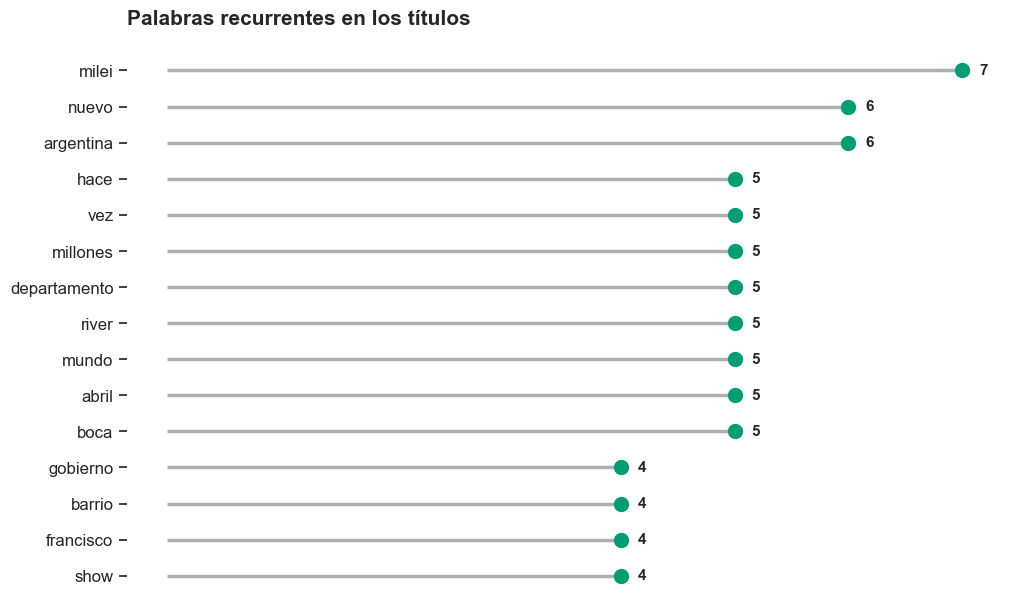

In [4]:
# EJERCICIO: Extraer el Top 15 de palabras más utilizadas en los títulos (ignorando stop words) y representarlas en un Lollipop Chart.
import stopwords_es

if 'df' in locals():
    # 1. Extracción y conteo (Igual que antes)
    todas_palabras = []
    for titulo in df['titulo']:
        palabras = re.findall(r'\b[a-z]{3,}\b', str(titulo).lower())
        todas_palabras.extend([p for p in palabras if p not in stopwords_es.stopwords_es])

    frecuencias = Counter(todas_palabras)
    
    # Creamos el DF y lo ordenamos COMPLETO, sin destruir las columnas
    top_palabras = pd.DataFrame(frecuencias.most_common(15), columns=['Palabra', 'Frecuencia'])
    top_palabras = top_palabras.sort_values(by='Frecuencia', ascending=True) 
    
    # Creación del lienzo
    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    
    # Dibujo de la estructura del Lollipop
    # Usamos top_palabras['Palabra'] para el eje Y
    ax.hlines(
        y=top_palabras['Palabra'],
        xmin=0,
        xmax=top_palabras['Frecuencia'],
        color='#b0b0b0',
        linewidth=2.5,
        zorder=1
    )
    
    ax.plot(
        top_palabras['Frecuencia'],
        top_palabras['Palabra'],
        'o',
        markersize=10,
        color=PALETA[2],
        zorder=2
    )
    
    # Usamos el nombre de la palabra para ubicar el texto en el eje Y
    for i, row in top_palabras.iterrows():
        ax.text(
            x=row['Frecuencia'] + 0.15, 
            y=row['Palabra'], 
            s=str(row['Frecuencia']), 
            va='center', 
            fontweight='bold', 
            fontsize=11
        )
        
    # Limpieza visual
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    sns.despine(left=True, bottom=True)
    
    ax.set_title('Palabras recurrentes en los títulos',
                 fontsize=15, fontweight='bold', pad=15, loc='left')
    
    plt.show()    
    """
    # 2. Generación del gráfico
    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    
    sns.barplot(
        data=top_palabras,
        y='Palabra',
        x='Frecuencia',
        hue='Palabra',
        palette='viridis', # Aplicamos una paleta continua para destacar variación leve
        ax=ax,
        legend=False
    )
    
    # Anotamos los valores precisos al final de cada barra
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=4, color='#333333', fontsize=10, fontweight='bold')
        
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    sns.despine(left=True, bottom=True)
    
    ax.set_title('Palabras de mayor frecuencia identificadas en los títulos',
                 fontsize=15, fontweight='bold', pad=15, loc='left')
    
    plt.show()
    """

## Consigna Final: Dashboard Dinámico de Sentido con Gradio

Integrar y escalar el diseño. Acaba de confirmar metodológicamente la agenda principal y el vocabulario dominador del periódico entero. Ahora envuélvalo funcionalmente convirtiéndolo en una Interface Web que logre desglosar el contenido respondiendo filtros particulares del investigador.

Deberá programar una Interfaz Gradio (`gr.Interface` o `gr.Blocks`) que exponga un **Desplegable (Dropdown)** poblado con las Secciones halladas (`Política`, `Economía`, `Sociedad`, etc.). 
La selección del usuario invocará una función que:
1. Cribe al DataFrame dejando solamente artículos pertenecientes a dicha sección.
2. Genere dos *outputs* (Salidas): 
    * Una tabla (`gr.Dataframe` o texto) enumerando puros títulos resultantes de esa sección selecta.
    * El gráfico del analizador de pesos (`Lollipop de frecuencias`) re-computado exclusivamente sobre el vocabulario de la sección elegida.

> Al correr la Interfaz, notará instantáneamente cómo el eje material y discursivo muta violentamente de polaridad con el simple acto interactivo de mover de 'Política' a 'Cultura'.

In [5]:
print(df.columns)
df.info()
df.head()
print(df['seccion'].value_counts())

Index(['seccion', 'titulo'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   seccion  137 non-null    str  
 1   titulo   137 non-null    str  
dtypes: str(2)
memory usage: 2.3 KB
seccion
ESPECTÁCULOS              23
ACTUALIDAD                14
General                   10
JARDÍN                    10
MÁS NOTICIAS               9
OTROS TEMAS                9
EXPERIENCIA LIVING         9
MOVILIDAD                  7
LIFESTYLE                  7
OPINIÓN                    6
HISTORIAS Y PERSONAJES     5
MÁS LEÍDAS                 5
INVERSIONES                5
POLÍTICA Y ECONOMÍA        4
DEPORTES                   4
TE PUEDE INTERESAR         4
EL MUNDO                   3
TECNOLOGÍA                 3
Name: count, dtype: int64


In [6]:
# EJERCICIO FINAL: Construir y lanzar la Interfaz Dinámica con Gradio
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
import stopwords_es
from collections import Counter

def filtrar_y_analizar(seccion_seleccionada):
    # 1. Filtrado del DataFrame
    df_filtrado = df[df['seccion'] == seccion_seleccionada].copy()
    
    # 2. Obtener lista de títulos para la tabla
    titulos_tabla = df_filtrado[['titulo']].reset_index(drop=True)
    
    # 3. Re-computar frecuencias para el Lollipop
    todas_palabras = []
    for titulo in df_filtrado['titulo']:
        palabras = re.findall(r'\b[a-z]{3,}\b', str(titulo).lower())
        todas_palabras.extend([p for p in palabras if p not in stopwords_es.stopwords_es])
    
    frecuencias = Counter(todas_palabras)
    top_palabras = pd.DataFrame(frecuencias.most_common(15), columns=['Palabra', 'Frecuencia'])
    top_palabras = top_palabras.sort_values(by='Frecuencia', ascending=True)
    
    # 4. Generar el Gráfico (Lollipop)
    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    
    if not top_palabras.empty:
        ax.hlines(y=top_palabras['Palabra'], xmin=0, xmax=top_palabras['Frecuencia'], 
                  color='#b0b0b0', linewidth=2.5, zorder=1)
        ax.plot(top_palabras['Frecuencia'], top_palabras['Palabra'], 'o', 
                markersize=10, color='#2ecc71', zorder=2) # Verde accesible
        
        for i, row in top_palabras.iterrows():
            ax.text(row['Frecuencia'] + 0.15, row['Palabra'], str(row['Frecuencia']), 
                    va='center', fontweight='bold')
    
    ax.set_title(f'Vocabulario Dominante: Sección {seccion_seleccionada}', fontsize=14, loc='right')
    sns.despine(left=True, bottom=True)
    ax.set_xticks([])
    
    return titulos_tabla, fig

# --- Construcción de la Interfaz ---

with gr.Blocks(title="Analizador de Sentido - Dashboard") as demo:
    gr.Markdown(f"# Dashboard Dinámico de Sentido\nAnálisis de agenda y vocabulario por sección.")
    
    with gr.Row():
        # Dropdown poblado dinámicamente desde el DF
        secciones = sorted(df['seccion'].unique().tolist())
        selector = gr.Dropdown(choices=secciones, label="Seleccione una Sección del Periódico", interactive=True)
    
    with gr.Tabs():
        with gr.TabItem("Análisis de Vocabulario"):
            plot_output = gr.Plot(label="Lollipop de Frecuencias")
        with gr.TabItem("Títulos de la Sección"):
            table_output = gr.Dataframe(headers=["Título"], interactive=False)

    # Vinculación lógica: Al cambiar el dropdown, se ejecutan las salidas
    selector.change(
        fn=filtrar_y_analizar,
        inputs=selector,
        outputs=[table_output, plot_output]
    )

# Lanzar la interfaz
if __name__ == "__main__":
    demo.launch()



* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.
